In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from PlanningDynamics import bootstrapPosteriors as bP
from sklearn.metrics import confusion_matrix
from copy import deepcopy
from scipy.stats import f_oneway

In [2]:
def find_covert_states(fname):
    data = nwbWrapper(fname, region="OFC")
    post = bP.load_posteriors(fname)
    trials = data.trial_df.query("trialerror == 0").trial.values
    all_states = pd.DataFrame()
    for trial in trials:
        trial_state_df = bP.state_df_boot(trial, data, post["state"]["posteriors"], post["plan"]["posteriors"], post["choice"]["posteriors"])
        if len(trial_state_df) > 0:    
            all_states = pd.concat([all_states, trial_state_df], ignore_index=True)
        
    #all_states = all_states.query("(current_value < 4)").reset_index(drop=True)
    all_states["plan_value_diff"] = all_states["plan_value"] - all_states["current_value"] 
    all_states["choice_value_diff"] = all_states["choice_value"] - all_states["current_value"] 
    all_states["filename"] = fname.split("/")[-1]
    return all_states

import pickle
save_path = "data/covert_states_dict.pkl"
if not os.path.exists(save_path):
    fnames = utils.get_filenames()
    covert_states_dict = {}
    for sbj in fnames.keys():
        for fname in fnames[sbj]:
            covert_states_dict[fname] = find_covert_states(fname)
    with open(save_path, "wb") as f:
        pickle.dump(covert_states_dict, f)
    print(f"Saved covert_states_dict to: {save_path}")
else:
    covert_states_dict = pickle.load(open(save_path, "rb"))
    print(f"File already exists, loaded {save_path}")

File already exists, loaded data/covert_states_dict.pkl


/media/eric/partition_1/PlanningDynamics/data/london/London_TeleWorld_4x4_100924_spikes.nwb


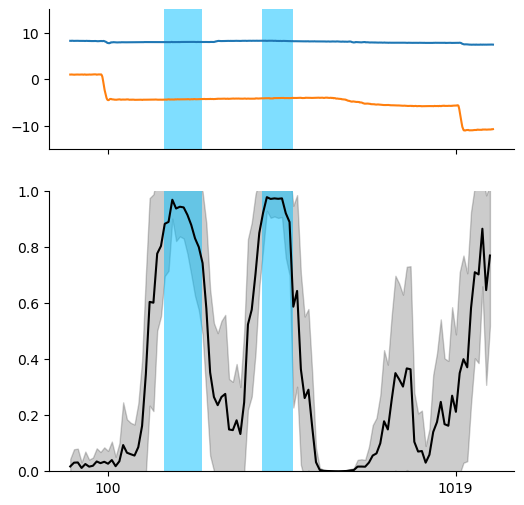

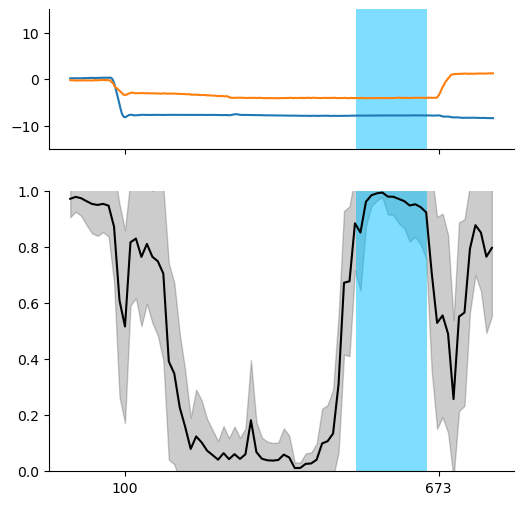

/media/eric/partition_1/PlanningDynamics/data/bart/Bart_TeleWorld_v13_033123.nwb


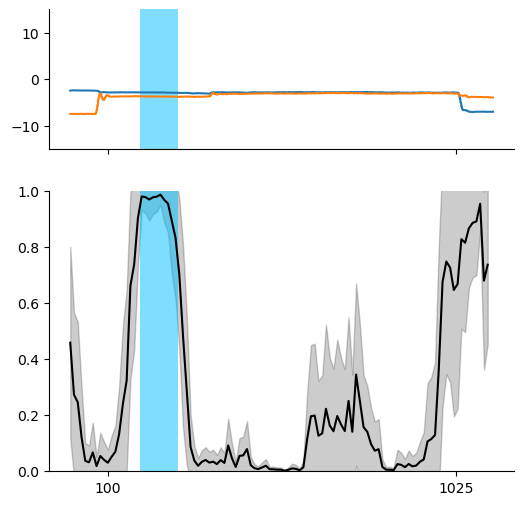

In [ ]:
from collections import namedtuple
state_to_plot = namedtuple("state_to_plot", ["sbj", "session", "trial", "step"])

def fig5A():
    def plot_example_state(data, covert_states, posteriors, state):
        cs = covert_states.query("trial == @state.trial and step == @state.step").reset_index(drop=True)
        eyes = data.trial_spikes[state.trial].eyes
        choice = data.choice_df.query("trial == @state.trial & step == @state.step").reset_index(drop=True)
        ts = utils.trial_ts(data.trial_spikes[state.trial])
        fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True, height_ratios= [0.5, 1])
        on, off = int((choice.fix_on.values - ts["ml_start_time"])[0]) - 100, int((choice.fix_off.values - ts["ml_start_time"])[0]) + 100
        ax[0].plot(eyes[on:off])
        post_idx = (posteriors["state"]["timesteps"][state.trial] <= off) & (posteriors["state"]["timesteps"][state.trial] >= on)
        mu = posteriors["state"]["posteriors"][state.trial].mean(axis=0)
        sig = posteriors["state"]["posteriors"][state.trial].std(axis=0) * 1.96
        ax[1].plot(np.arange(0, len(mu[post_idx, 1])*10, 10), mu[post_idx, 1], color="black", label="Posterior of current state")
        ax[1].fill_between(np.arange(0, len(mu[post_idx, 1])*10, 10), mu[post_idx, 1] - sig[post_idx, 1], mu[post_idx, 1] + sig[post_idx, 1], color="black", alpha=0.2)
        ax[1].set_ylim([0, 1])
        ax[0].set_ylim([-15, 15])
        ax[1].set_xticks([100, len(eyes[on:off]) - 100])
        for i in range(2):
            for _, c in cs.iterrows():
                ax[i].axvspan(c.state_on - (on), c.state_off - (on), color="deepskyblue", linestyle="none", alpha=0.5)
        
        sns.despine()
        plt.show()

    fnames = utils.get_filenames()
    
    states_to_plot = [state_to_plot("london", "100924", 116, 2),
                    state_to_plot("london", "100924", 225, 0),
                    state_to_plot("bart", "033123", 145, 1)]
    
    prev_state_session = None
    for state in states_to_plot:
        if state.session != prev_state_session:
            fname = [f for f in fnames[state.sbj] if state.session in f][0]
            data = nwbWrapper(fname, region="OFC")
            covert_states = covert_states_dict[fname].query("duration >= 60")
            posteriors = bP.load_posteriors(fname, vars_to_load=["state"])
            prev_state_session = state.session
            
        plot_example_state(data, covert_states, posteriors, state)
    return 

fig5A()

# Panel B: Leave-one-neuron-out analysis.
Note: this will take a long time to run, and will take a lot of memory. Best to run overnight on a powerful machine.

In [ ]:
from tqdm import tqdm
def bootstrap_leave_one_neuron_out(data, Xy_func, n_bootstraps, n_samples_per_class):
    X, y, X_by_trial = Xy_func(data)
    trials = data.trial_df.query("trialerror == 0").trial.values
    n_classes = len(np.unique(y))
    n_neurons = X.shape[1]
    posteriors = {}
    minibatches = bP.batch_trials(trials, 10)
    
    for minibatch in tqdm(minibatches):
        train_idx = bP.train_idx_for_minibatch(X_by_trial, minibatch)
        step_size=10
        X_boot, y_boot = bP.bootstrap_distribution(X[train_idx], y[train_idx], n_bootstraps=n_bootstraps, n_samples_per_class=n_samples_per_class)
        for neuron in range(n_neurons):
            models = []
            if neuron not in posteriors:
                posteriors[neuron] = {}
            loo_idx = (np.arange(n_neurons) != neuron).flatten()
            for j in range(n_bootstraps):
                model = bP.make_classifier()
                model.fit(X_boot[j, :, loo_idx].T, y_boot)
                models.append(deepcopy(model))
            for trial in minibatch: 
                t = np.arange(0, data.trial_spikes[trial].neural.shape[0], step_size).astype(np.int16)
                trial_posteriors = np.zeros([n_bootstraps, len(t), n_classes])    
                X_trial = utils.matrix_square_window(data.trial_spikes[trial].neural, [75, 75], step_size)
                for j in range(n_bootstraps):
                    trial_posteriors[j, ...] = models[j].predict_proba(X_trial[:, loo_idx])
                trial_posteriors_summary = np.vstack([trial_posteriors[..., 1].mean(axis=0), 
                                            trial_posteriors[..., 1].std(axis=0)]).T
                posteriors[neuron][trial] = trial_posteriors_summary
    return posteriors 

def plot_example_neuron(data, covert_state_spike_table, R, state_df, neuron):
    duration_sort_idx = np.argsort(state_df.duration.values)
    
    sns.set(style="ticks")
    fig, ax = plt.subplots(2, 1, figsize=(4, 5), height_ratios=[1, 3], sharex=True, tight_layout=True)
    X = utils.movmean(covert_state_spike_table[..., neuron], [75, 75])*1000
    t = np.arange(-500, 500)

    R_ = utils.movmean(R[..., neuron], 50)*1000
    ax[1].plot(t, R_.mean(axis=0), c="k", label="Random Times")

    ax[1].fill_between(t, R_.mean(axis=0) - utils.sem(R_, axis=0),
                        R_.mean(axis=0) + utils.sem(R_, axis=0), alpha=0.3, color="k", 
                        lw=0)


    ax[1].plot(t, X.mean(axis=0), c="deepskyblue", label="Covert States")

    ax[1].fill_between(np.arange(-500, 500),
                        X.mean(axis=0) - utils.sem(X, axis=0),
                        X.mean(axis=0) + utils.sem(X, axis=0), alpha=0.3, color="deepskyblue",
                        lw=0)

    ax[1].axvline(0, color="k", linestyle="--")

    Y, X = np.where(covert_state_spike_table[duration_sort_idx, :, neuron])
    ax[0].scatter(X-500, Y, s=1, c="k", marker="|")
    ax[0].set_ylim(0, covert_state_spike_table.shape[0])
    ax[0].axvline(0, color="k", linestyle="--")
    ax[0].set_xlim([-500, 500])

    ax[0].plot(state_df.duration.values[duration_sort_idx], np.arange(0, covert_state_spike_table.shape[0]), lw=1, c="deepskyblue")
    ax[0].set_xticks([-500, 0, 500])
    ax[0].set_yticks([0, covert_state_spike_table.shape[0]])
    ax[1].set_ylabel("FR (Hz)")
    ax[1].legend(frameon=False, loc="lower left", fontsize=9)
    ax[0].set_title("Unit {}: Covert State spikes\nSubject {}, Session {}".format(neuron, data.sbj[0].capitalize(), data.session))
    ax[1].set_xlabel("Time from state on (ms)")
    ax[0].set_ylabel("Covert State #")
    sns.despine()
    plt.show()
    
def state_df_boot(neuron, trial, data, state_posteriors):
    #timesteps = timesteps[trial]
    trial_steps = data.choice_df.query("trial == @trial")
    current_value = 4 - np.clip(trial_steps.loc[:, "graph_distance"].copy().values, 0, 3)
    _d = data.trial_spikes[trial]
    timesteps = np.arange(0, _d.neural.shape[0], 10).astype(np.int16)
    ts = utils.trial_ts(_d)
    #step_on, step_off = trial_steps[["fix_on", "fix_off"]] - ts["ml_start_time"]
    step_on = trial_steps["fix_on"].values - ts["ml_start_time"]
    step_off = trial_steps["fix_off"].values - ts["ml_start_time"]
    step_on, step_off

    #ci95 = confidence_interval(state_posteriors[trial][:, :, 1], confidence=0.95, axis=0)
    ci95 = state_posteriors[neuron][trial][:, 0] - 1.96*state_posteriors[neuron][trial][:, 1]
    states = bP.find_states(ci95, prob_threshold=0.5, duration_threshold=3, step_size=1)
    if states is None:
        return pd.DataFrame()

    states = timesteps[states]
    durations = (states[:, 1] - states[:, 0]).reshape(-1, 1)
    state_overlap_with_fix = utils.check_overlap_lists(states, np.hstack([step_on.reshape(-1, 1), step_off.reshape(-1, 1)])) / durations.reshape(-1, 1)
    valid_state_id, fix_id = np.where(state_overlap_with_fix >= 0.75)


    state_dict = dict(trial = trial,
                    step=fix_id,
                    current_value = current_value[fix_id],
                    duration = durations[valid_state_id, 0],
                    dist = trial_steps.iloc[fix_id, :].graph_distance.values,
                    ml_start_time = ts["ml_start_time"],
                    state_on = states[valid_state_id, 0],
                    state_off = states[valid_state_id, 1],
                    nodes = trial_steps.iloc[fix_id, :].nodes.values,
                    nsteps = len(trial_steps),
                    )
    state_df = pd.DataFrame(state_dict)
    return state_df

def state_df_session(neuron, data, posteriors):
    #trials = data.trial_df.query("trialerror == 0").trial.values
    trials = list(posteriors[neuron].keys())
    state_dfs = []
    for trial in trials:
        state_df = state_df_boot(neuron, trial, data, posteriors)
        if not state_df.empty:
            state_dfs.append(state_df)
    state_dfs = pd.concat(state_dfs, ignore_index=True)
    return state_dfs

def random_spike_table(data, n_samples, w=750):
    
    def choice_times(data, trial):
        ts = utils.trial_ts(data.trial_spikes[trial])
        start_time = int(ts["ml_start_time"])
        trial_row = data.choice_df.query("trial == @trial")
        trial_choice_times = np.concatenate([np.arange(a, b) for a, b in zip((trial_row.fix_on - start_time).values, (trial_row.fix_off - start_time).values)])
        trial_end = ts["reward"] - 500
        trial_choice_times = trial_choice_times[trial_choice_times < trial_end]
        return trial_choice_times
    
    spike_table = np.zeros([n_samples, w*2, data.n_cells])
    trials = data.trial_df.query("trialerror == 0").trial.values
    random_trials = np.random.choice(trials, n_samples, replace=True)
    
    for i, trial in enumerate(random_trials):
        #n_time = data.trial_spikes[trial].neural.shape[0]
        choice_times_trial = choice_times(data, trial)
        choice_times_trial = choice_times_trial[choice_times_trial >= w]
        t = np.random.choice(choice_times_trial)
        spike_table[i, ...] = data.trial_spikes[trial].neural[t-w:t+w, :]
    return spike_table

def covert_state_modulation(unit, R, unit_spikes, w = 750):
    t = np.arange(0, w*2, 10) + 5
    R_ = utils.movmean(R[..., unit], 50)*1000
    R_ = R_[:, t]
    f_stats = []
    p_vals = []
    for t_ in range(len(t)):
        x_, r_ = unit_spikes[:, t_], R_[:, t_]
        f_stat, p_val = f_oneway(x_, r_)
        f_stats.append(f_stat)
        p_vals.append(p_val)
    f_stats = np.array(f_stats)
    p_vals = np.array(p_vals)
    return dict(f=f_stats, p=p_vals)

def run_LONO_summary(fname, n_iters=100):
    data = nwbWrapper(fname, region="OFC")
    posteriors = bootstrap_leave_one_neuron_out(data, bP.data_for_state_model, n_bootstraps=100, n_samples_per_class=1000)
    w=750
    p_final = np.zeros([n_iters, data.n_cells, (w*2)//10])
    spike_tables = {}
    R = random_spike_table(data, 1000)
    
    neurons_to_plot = {"bart":{"033123":7}, 
                   "london":{"100324":36, "101124":72}}
    neuron_to_plot = None
    if data.session in neurons_to_plot[data.sbj]:
        neuron_to_plot = neurons_to_plot[data.sbj][data.session]
    
    for neuron in range(data.n_cells):
        state_df = state_df_session(neuron, data, posteriors)
        spike_table = np.zeros([state_df.shape[0], w*2, data.trial_spikes[0].neural.shape[1]])    
        trial = -1
        for i, row in state_df.reset_index().iterrows():
            if row["trial"] != trial:
                trial = row["trial"]
                trial_spikes = data.trial_spikes[trial].neural
            state_on = int(row["state_on"])
            row_spikes = trial_spikes[(state_on-w):(state_on+w), :]
            spike_table[i, :row_spikes.shape[0], :] = row_spikes
        X_ = utils.movmean(spike_table[..., neuron], 50)*1000
        t = np.arange(0, w*2, 10) + 5
        X_ = X_[:, t]
        spike_tables[neuron] = X_.copy()
        if neuron_to_plot is not None and neuron == neuron_to_plot:
            plot_example_neuron(data, spike_table, R, state_df, neuron)
        del X_, state_df, spike_table
        
    for j in range(n_iters):
        R = random_spike_table(data, 1000, w=w)
        anova_res = []
        for neuron in range(data.n_cells):
            anova_res.append(covert_state_modulation(neuron, R, spike_tables[neuron]))

        p_table = np.zeros([data.n_cells, (w*2)//10])
        for i, _res in enumerate(anova_res):
            p_table[i, :] = _res["p"]
        del anova_res
        p_final[j, ...] = p_table

    return p_final

def fig5B_C(res):
    p_summary = {}
    for sbj in res:
        p_summary[sbj] = []
        for session in utils.eSession(sbj):
            p_summary[sbj].append(res[sbj][session])
        p_summary[sbj] = np.concatenate(p_summary[sbj], axis=1)
        
    sns.set(style="ticks")
    fig, ax = plt.subplots(1, 2, figsize=(6, 4), constrained_layout=True, sharey=False, sharex=True)
    for i, sbj in utils.eSbj():

        X = np.mean(p_summary[sbj] < 0.01, axis=1)*100
        t = np.arange(-750, 750, 10)
        
        mu = X.mean(axis=0)
        err =  X.std(axis=0)*1.96
        
        ax[i].plot(t, mu, c="k")
        
        ax[i].fill_between(t, mu - err , mu + err, alpha=0.3, color="k", linewidth=0)
        ax[i].set_xlim([-700, 700])
        ax[i].set_xticks([-700, -350, 0, 350, 700])
        ax[i].axvline(0, ls="--", c="k")
        ax[i].axhline(1, ls="-", c="red")
        ax[i].set_title("Sbj %s" % sbj.capitalize()[0])
    ax[0].set_ylabel("Time from state onset (ms)")
    ax[0].set_ylim([0, 12])
    ax[0].set_yticks([0, 6, 12])
    ax[1].set_ylim([0, 22])
    ax[1].set_yticks([0, 11, 22])
    sns.despine()

    ax[0].set_ylabel("Significant neurons (%)")
    plt.show()
    
LONO_res = utils.iterate_subjects(fnames, run_LONO_summary)
fig5B_C(LONO_res)

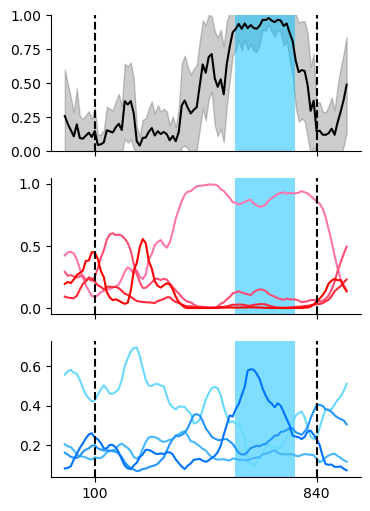

In [ ]:
def fig5E():
    state = state_to_plot("london", "100924", 605, 0)
    fname = [f for f in fnames[state.sbj] if state.session in f][0]
    data = nwbWrapper(fname, region="OFC")
    covert_states = covert_states_dict[fname].query("duration >= 60")
    posteriors = bP.load_posteriors(fname, vars_to_load=["state", "plan", "choice"])
    cs = covert_states.query("trial == @state.trial and step == @state.step").reset_index(drop=True)
    choice = data.choice_df.query("trial == @state.trial & step == @state.step").reset_index(drop=True)
    ts = utils.trial_ts(data.trial_spikes[state.trial])
    
    fig, ax = plt.subplots(3, 1, figsize=(4, 6), sharex=True)
    choice_colors = plotting.interpolate_colors(color2="#ff0000", color1="#ff75ac", num_colors=4)
    plan_colors = plotting.interpolate_colors(color2="#0073ff", color1="#69d9ff", num_colors=4)

    on, off = int((choice.fix_on.values - ts["ml_start_time"])[0]) - 100, int((choice.fix_off.values - ts["ml_start_time"])[0]) + 100
    post_idx = (posteriors["state"]["timesteps"][state.trial] <= off) & (posteriors["state"]["timesteps"][state.trial] >= on)
    t = np.arange(0, post_idx.sum()*10, 10)
    
    mu = posteriors["state"]["posteriors"][state.trial].mean(axis=0)
    sig = posteriors["state"]["posteriors"][state.trial].std(axis=0) * 1.96
    choice_mu = utils.movmean(posteriors["choice"]["posteriors"][state.trial].mean(axis=0).T, 2).T
    plan_mu = utils.movmean(posteriors["plan"]["posteriors"][state.trial].mean(axis=0).T, 2).T
    
    ax[0].plot(t, mu[post_idx, 1], color="black", label="Posterior of current state")
    ax[0].fill_between(t, mu[post_idx, 1] - sig[post_idx, 1], mu[post_idx, 1] + sig[post_idx, 1], color="black", alpha=0.2)
    ax[0].set_ylim([0, 1])
    
    for k in range(4):
        ax[1].plot(t, choice_mu[post_idx, k], color=choice_colors[k])
        ax[2].plot(t, plan_mu[post_idx, k], color=plan_colors[k])

    ax[0].set_xticks([100, t[-1] - 100])
    for i in range(3):
        for _, c in cs.iterrows():
            ax[i].axvspan(c.state_on - (on), c.state_off - (on), color="deepskyblue", linestyle="none", alpha=0.5)
            ax[i].axvline(100, color="k", linestyle="--")
            ax[i].axvline(t[-1] - 100, color="k", linestyle="--")
    sns.despine()
    return fig, ax
    
fig, ax = fig5E()
plt.show()

In [ ]:
import pickle
from pathlib import Path

def fig5D_data():
    def run(fname): 
        global covert_states_dict
        if ("covert_states_dict" not in globals()) or (covert_states_dict is None):
            with open("data/covert_states_dict.pkl", "rb") as f:
                covert_states_dict = pickle.load(f)  

        def load_data(fname, covert_states_dict):
                data = nwbWrapper(fname, region="OFC")
                covert_states = covert_states_dict[fname].query("duration >= 60")
                plan_data = utils.get_plan_data(data)
                posteriors = bP.load_posteriors(fname, vars_to_load=["plan", "state"])
                return data, covert_states, plan_data, posteriors
                    
        def get_matched_states(data, covert_states, post):
            matched_choice_states = pd.DataFrame()
            for _, row in covert_states.iterrows():
                trial, step = row.trial, row.step
                step_on, step_off = (data.choice_df.query("trial == %i & step == %i" % (trial, step)).iloc[0][["fix_on", "fix_off"]]) - row.ml_start_time

                ts = post["state"]["timesteps"][trial]
                t_idx = np.where((ts > step_on) & (ts < step_off))[0]
                choice_post_trace = post["state"]["posteriors"][trial][:, t_idx, 0]
                choice_err = choice_post_trace.std(axis=0)*1.96
                lower_bound = choice_post_trace.mean(axis=0) - choice_err

                #state times are in ms relative to the start of the trial
                choice_states = (bP.find_states(lower_bound, 0.5, 3, 1))
                if choice_states is not None:
                    choice_states = choice_states * 10 + ts[t_idx[0]]  # convert to ms and get time relative to trial start
                    _df = pd.DataFrame(choice_states, columns=["state_on", "state_off"])
                    _df["ml_start_time"] = row.ml_start_time
                    _df["trial"] = row.trial
                    _df["step"] = row.step
                    _df["duration"] = (_df["state_off"] - _df["state_on"]).astype(int)
                    matched_choice_states = pd.concat([matched_choice_states, _df])
            return matched_choice_states.reset_index(drop=True)

        def matched_posteriors(covert_states_session, post, matched_choice_states):
            trial = None
            post_during_state = []
            post_outside_state = []
            current_value = []
            
            for _, row in covert_states_session.reset_index().iterrows():
                if trial != row.trial:
                    trial = row.trial
                    plan_trace = post["plan"]["posteriors"][trial]
                
                step = row.step
                matched_states = matched_choice_states.query("(trial == %i & step == %i) & (duration >= 60)" % (trial, step))
                if matched_states.empty:
                    continue    
                
                matched_state = matched_states.iloc[np.argmax(matched_states.duration)]
                state_on, state_off = int(row.state_on/10), int(row.state_off/10)
                match_on, match_off = int(matched_state.state_on/10), int(matched_state.state_off/10)
                
                post_during_state.append(plan_trace[:, state_on:state_off, :].mean(axis=1))
                post_outside_state.append(plan_trace[:, match_on:match_off, :].mean(axis=1))
                current_value.append(row.current_value)
                
            post_during_state = np.array(post_during_state)
            post_outside_state = np.array(post_outside_state)
            current_value = np.array(current_value)
            return post_during_state, post_outside_state, current_value

        def bhv_cm(plan_data):
            current_node_distance = plan_data["df"].apply(lambda row: graph.distance(row.node_on, row.target), axis=1)
            current_node_value = utils.distance_to_value(current_node_distance)
            plan_value = utils.distance_to_value(plan_data["df"].graph_distance.values)    
            return confusion_matrix(current_node_value, plan_value).T[:, :3]

        def compute_confusion_matrices(plan_data, post_during_state, post_outside_state, current_value):
            """
            Compute the KL divergence between the posterior distributions during the state and outside the state.
            """
            state_cms = np.zeros((1000, 4, 3))
            match_cms = np.zeros((1000, 4, 3))
            cm_bhv = bhv_cm(plan_data)

            pred_during_state = post_during_state.argmax(axis=2) + 1
            pred_outside_state = post_outside_state.argmax(axis=2) + 1
            for i in range(1000):
                confusion_matrix_during = confusion_matrix(current_value, pred_during_state[:, i]).T[:, :3]
                counfusion_matrix_outside = confusion_matrix(current_value, pred_outside_state[:, i]).T[:, :3]

                state_cms[i] = confusion_matrix_during
                match_cms[i] = counfusion_matrix_outside
            return dict(
                state_cms=state_cms,
                match_cms=match_cms,
                bhv_cm=cm_bhv,
            )
            
        data, covert_states, plan_data, post = load_data(fname, covert_states_dict)
        matched_choice_states = get_matched_states(data, covert_states, post)
        post_during_state, post_outside_state, current_value = matched_posteriors(covert_states, post, matched_choice_states)
        cms = compute_confusion_matrices(plan_data, post_during_state, post_outside_state, current_value)
        return cms

    return utils.iterate_subjects(fnames, run)

def fig5D(fig_data):
    def kde_distribution(arr):
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(arr)
        x_values = np.linspace(0, 1, 500)
        kde_val = kde(x_values)
        return x_values, kde_val

    fig, ax = plt.subplots(2, 1, figsize=(5, 5), constrained_layout=True)
    state_cms = {}
    bhv_cms = {}
    match_cms = {}
    for j, sbj in enumerate(fig_data.keys()):

        state_cms[sbj] = []
        match_cms[sbj] = []
        bhv_cms[sbj] = []
        for session in range(len(fig_data[sbj])):
            state_cms[sbj].append(fig_data[sbj][session]["state_cms"][np.newaxis, ...])
            match_cms[sbj].append(fig_data[sbj][session]["match_cms"][np.newaxis, ...])
            bhv_cms[sbj].append(fig_data[sbj][session]["bhv_cm"])
        state_cms[sbj] = np.concatenate(state_cms[sbj])
        match_cms[sbj] = np.concatenate(match_cms[sbj])
        bhv_cms[sbj] = np.array(bhv_cms[sbj])
        bhv_cms[sbj] = bhv_cms[sbj].sum(axis=0)
        bhv_cms[sbj] = bhv_cms[sbj] / bhv_cms[sbj].sum(axis=0, keepdims=True)
        state_cms[sbj] = state_cms[sbj].sum(axis=0)
        match_cms[sbj] = match_cms[sbj].sum(axis=0)

        state_kls = np.zeros(1000)
        match_kls = np.zeros(1000)

        for i in range(state_cms[sbj].shape[0]):
            state_cms[sbj][i] = state_cms[sbj][i]/state_cms[sbj][i].sum(axis=0, keepdims=True)
            match_cms[sbj][i] = match_cms[sbj][i]/match_cms[sbj][i].sum(axis=0, keepdims=True)
            state_kls[i] = utils.kl_divergence(state_cms[sbj][i].flatten(), bhv_cms[sbj].flatten()) 
            match_kls[i] = utils.kl_divergence(match_cms[sbj][i].flatten(), bhv_cms[sbj].flatten()) 

        c="deepskyblue"
        h = 1.1
        x, y = kde_distribution(state_kls)
        y=y/y.max()
        ax[j].plot(x, y, c=c, label="Covert plans")
        ax[j].fill_between(x, np.zeros_like(x), y, alpha=0.5, color=c)
        ax[j].scatter(state_kls.mean(), h, c=c, s=20)
        CI = utils.confidence_interval(state_kls)
        ax[j].plot(CI, [h, h], c=c)
        
        c="red"
        x, y = kde_distribution(match_kls)
        y=y/y.max()
        ax[j].plot(x, y, c=c, label="Matched choices")
        ax[j].fill_between(x, np.zeros_like(x), y, alpha=0.5, color=c)
        CI = utils.confidence_interval(match_kls)
        ax[j].plot(CI, [h, h], c=c)
        ax[j].scatter(match_kls.mean(), h, c=c, s=20)
        ax[j].set_ylabel("Density")
        
        ax[j].set_yticks([0, 1], labels=["0", "1"])
        ax[j].set_title(f"Sbj: {sbj[0].capitalize()}")
        ax[j].set_ylim([0, 1.3])
        
    ax[0].set_xlim([0, 1])
    ax[0].set_xticks([0, 0.5, 1])

    ax[1].set_xlim([0, 1])
    ax[1].set_xticks([0, 0.5, 1])
    ax[1].set_xlabel("KL divergence to overt plans")
    ax[0].legend(fontsize=9, frameon=False)
    sns.despine()
    plt.show()
    
    vmax_1 = 60
    vmax_2 = 40
    for j, sbj in enumerate(fig_data.keys()):
        fig, ax = plt.subplots(2, 1, figsize=(5, 6), constrained_layout=True)
        im = ax[0].imshow(bhv_cms[sbj]*100, cmap="gray", vmin=0, vmax=vmax_1)
        plt.colorbar(im, ax=ax[0], ticks=[0, 30, 60])
        ax[0].set_yticks([0, 1, 2, 3], labels=["1", "2", "3", "4"])
        ax[0].set_xticks([0, 1, 2], labels=["1", "2", "3"])
        ax[0].set_ylabel("Overt Value")
        
        im = ax[1].imshow(state_cms[sbj].mean(axis=0)*100, cmap="Blues_r", vmin=20, vmax=vmax_2)
        plt.colorbar(im, ax=ax[1], ticks=[20, 30, 40])
        ax[1].set_yticks([0, 1, 2, 3], labels=["1", "2", "3", "4"])
        ax[1].set_xticks([0, 1, 2], labels=["1", "2", "3"])
        ax[1].set_ylabel("Covert Value")
        ax[1].set_xlabel("Current Value")
        ax[0].set_title("Sbj {}".format(sbj[0].capitalize()))
        plt.show()

fig5D_data = fig5D_data()
fig5D(fig5D_data)

In [ ]:
def run_fig5G():
    global covert_states_dict
    if ("covert_states_dict" not in globals()) or (covert_states_dict is None):
        with open("/media/eric/partition_1/PlanningDynamics/data/covert_states_dict.pkl", "rb") as f:
            covert_states_dict = pickle.load(f)  

    def load_data(fname, covert_states_dict):
            data = nwbWrapper(fname, region="OFC")
            covert_states = covert_states_dict[fname].query("duration >= 60")
            plan_data = utils.get_plan_data(data)
            return data, covert_states, plan_data

    from sklearn.model_selection import cross_val_predict
    from sklearn.utils import resample

    def covert_state_spike_table(data, covert_states):
        spike_table = np.zeros((covert_states.shape[0], data.n_cells))
        for i, row in covert_states.reset_index().iterrows():
            trial = row.trial
            start = int(row.state_on)
            end = int(row.state_off)
            spike_table[i, :] = data.trial_spikes[trial].neural[start:end].mean(axis=0)
        return spike_table, covert_states.current_value.values
    
    def run_overt_vs_covert(fname, n_bootstraps=100):
        data, covert_states, plan_data = load_data(fname, covert_states_dict)
        X_covert, y_covert = covert_state_spike_table(data, covert_states)
        X = plan_data["spikes"]
        y = utils.distance_to_value(plan_data["df"].graph_distance.values)
        model = bP.make_classifier()
        counts = np.bincount(y)
        counts = counts[counts!= 0]
        samples_per_class = 250
        bootstrap_cm_covert = np.zeros([n_bootstraps, 4, 4])
        bootstrap_cm_overt = np.zeros([n_bootstraps, 4, 4])
        covert_value_diff = np.zeros([n_bootstraps, X_covert.shape[0]])
        overt_value_diff = np.zeros([n_bootstraps, samples_per_class*4])
        covert_pred = np.zeros([n_bootstraps, X_covert.shape[0]])
        covert_post = np.zeros([n_bootstraps, X_covert.shape[0], 4])
        covert_true = y_covert
        random_state = np.arange(0, n_bootstraps)
        
        for j in range(n_bootstraps):
            X_balanced, y_balanced = [], []
            for i in range(1, 5):
                X_i = X[y == i]
                y_i = y[y == i]
                X_sample, y_sample = resample(X_i, y_i, n_samples=samples_per_class, random_state=random_state[j], replace=True)
                X_balanced.append(X_sample)
                y_balanced.append(y_sample)
                
            X_balanced = np.concatenate(X_balanced)
            y_balanced = np.concatenate(y_balanced) 
            
            model.fit(X_balanced, y_balanced)
            y_pred_covert = model.predict(X_covert)
            y_pred_overt = cross_val_predict(model, X_balanced, y_balanced, cv=5, verbose=0, n_jobs=1)
            bootstrap_cm_covert[j] = confusion_matrix(y_covert, y_pred_covert, normalize="true")
            bootstrap_cm_overt[j] = confusion_matrix(y_balanced, y_pred_overt, normalize="true")
            covert_value_diff[j] = y_pred_covert - y_covert
            overt_value_diff[j] = y_pred_overt - y_balanced
            covert_pred[j, ...] = y_pred_covert
            covert_post[j, ...] = model.predict_proba(X_covert)

        return dict(
            covert_cm=bootstrap_cm_covert,
            overt_cm=bootstrap_cm_overt,
            covert_diff = covert_value_diff,
            overt_diff = overt_value_diff,
            covert_df = covert_states,
            covert_pred = covert_pred,
            covert_true = covert_true,
        )
        
    return utils.iterate_subjects(fnames, run_overt_vs_covert)

def fig5G(fig_data):
    sbj_res = {}
    for sbj in fig_data.keys():
        n_bootstraps = 100
        n_sessions = len(fig_data[sbj])
        covert_pred_all = []
        covert_true_all = []
        overt_cm_all = []
        for session in range(n_sessions):
            covert_pred_all.append(fig_data[sbj][session]["covert_pred"])
            covert_true_all.append(fig_data[sbj][session]["covert_true"])
            overt_cm_all.append(fig_data[sbj][session]["overt_cm"])
        covert_pred_all = np.concatenate(covert_pred_all, axis=1)
        covert_true_all = np.concatenate(covert_true_all)
        overt_cm_all = np.mean(np.array(overt_cm_all), axis=0)
        covert_cm_all = []
        overt_weighted_value_diff = np.zeros([n_bootstraps])
        covert_weighted_value_diff = np.zeros([n_bootstraps])
        B = np.array([i - np.arange(4) for i in range(4)])
            
        for i in range(n_bootstraps):
            A = confusion_matrix(y_true=covert_true_all, y_pred=covert_pred_all[i], normalize="true").T
            covert_cm_all.append(A)
            covert_weighted_value_diff[i] = np.sum(A * B)
                
            A = overt_cm_all[i].T
            overt_weighted_value_diff[i] = np.sum(A * B)
        covert_cm_all = np.mean(np.array(covert_cm_all), axis=0)
        sbj_res[sbj] = dict(covert_value_diff=covert_weighted_value_diff,
                        overt_value_diff=overt_weighted_value_diff,
                        overt_cm=overt_cm_all,
                        covert_cm = covert_cm_all) 
        
    from scipy.stats import gaussian_kde, ttest_ind
    fig, ax = plt.subplots(2, 1, figsize=(4, 3), constrained_layout=True, sharex=True)
    for i, sbj in enumerate(fig_data.keys()):
        covert_weighted_value_diff = sbj_res[sbj]["covert_value_diff"]
        kde = gaussian_kde(covert_weighted_value_diff)
        x_values = np.linspace(-1.5, 1.5, 1000)  # Define the range for x values
        covert_kde_values = kde(x_values)  # Get the density values
        covert_kde_values /= covert_kde_values.max()
        ax[i].plot(x_values, covert_kde_values, label="Covert KDE", color="deepskyblue")
        ax[i].fill_between(x_values, np.zeros_like(x_values), covert_kde_values, color="deepskyblue", alpha=0.5)

        overt_weighted_value_diff = sbj_res[sbj]["overt_value_diff"]
        kde = gaussian_kde(overt_weighted_value_diff)
        overt_kde_values = kde(x_values)  # Get the density values
        overt_kde_values /= overt_kde_values.max()
        ax[i].plot(x_values, overt_kde_values, label="Overt KDE", color="k")
        ax[i].fill_between(x_values, np.zeros_like(x_values), overt_kde_values, color="k", alpha=0.5)
        ax[i].set_xlim([-1.4, 1.4])
        ax[i].set_xticks([-1.4, -0.7, 0, 0.7, 1.4])
        ax[i].set_ylim([0, 1.1])
        ax[i].set_title("Sbj %s" % sbj.capitalize()[0])
    ax[1].set_xlabel("weighted value difference")
    sns.despine()

    for i, sbj in enumerate(fig_data.keys()):
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        overt_cm_all = sbj_res[sbj]["overt_cm"].mean(axis=0)
        im = ax[0].imshow(overt_cm_all.T, vmin=0.15, vmax=0.45, cmap="Blues_r")
        covert_cm_all = sbj_res[sbj]["covert_cm"]
        im = ax[1].imshow(covert_cm_all, vmin=0.15, vmax=0.45, cmap="Blues_r")
        fig.suptitle("Sbj %s" % sbj.capitalize()[0])
        plt.show()

fig5G_data = run_fig5G()
fig5G(fig5G_data)

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 594.75it/s]


loading choice data:


100%|██████████| 563/563 [00:00<00:00, 2657.22it/s]


...

100%|██████████| 943/943 [00:01<00:00, 620.46it/s]


loading choice data:


100%|██████████| 943/943 [00:00<00:00, 2549.79it/s]


Samples per class: 250


Processing london: 100%|██████████| 7/7 [01:17<00:00, 11.13s/it]


In [ ]:
def suppFig4():
  def run(fname):
      calculate_steps_saved = lambda row: graph.distance(row.start, row.target, type="space") - graph.distance(row.start, row.target, type="graph")
      data = nwbWrapper(fname, region="OFC")
      trial_df = data.trial_df.query("trialerror == 0").copy()
      choice_df = data.choice_df.query("(trialerror == 0)").copy()
      
      trial_df["steps_saved"] = trial_df.apply(calculate_steps_saved, axis=1)
      trial_df["use_tele"] = trial_df["steps_saved"] >= 1
      trial_df["optimal_steps"] = trial_df.apply(lambda row: graph.distance(row.start, row.target, type="tele"), axis=1)

      reward_time = np.zeros(len(trial_df))
      
      for i, row in trial_df.reset_index().iterrows():
          trial_ts = utils.trial_ts(data.trial_spikes[int(row.trial)])
          reward_time[i] = trial_ts["reward"]
      trial_df["reward_on"] = reward_time

      n_trials = trial_df.shape[0]
      n_covert_states = np.zeros([n_trials, ])
      choice_duration = np.zeros([n_trials, ])
      covert_state_duration = np.zeros([n_trials, ])
      state_df_session = covert_states_dict[fname]
      for i, row in trial_df.reset_index().iterrows():
        state_row = state_df_session.query("(trial == @row.trial) & (duration >= 60) & (step == 1)")
        n_covert_states[i] = state_row.shape[0]
        if n_covert_states[i] != 0:
          covert_state_duration[i] = state_row.duration.values[0]
        choice_row = choice_df.query("(trial == @row.trial) & (step == 1)")
        trial_start_time = row.start_time
        fix_on = choice_row.fix_on.values - trial_start_time
        fix_off = np.minimum(choice_row.fix_off.values - trial_start_time, row.reward_on)
        choice_duration[i] = (fix_off - fix_on)[0]

      trial_df["n_covert_states"] = n_covert_states    
      trial_df["covert_state_rate"] = trial_df["n_covert_states"] / choice_duration
      trial_df["start_distance"] = trial_df.apply(lambda row: graph.distance(row.start, row.target, type="tele"), axis=1)
      
      return dict(trial_df = trial_df, choice_df=choice_df)
  res_bhv = utils.iterate_subjects(fnames, run)
  
  from scipy.stats import ttest_rel, ttest_ind
  fig, ax = plt.subplots(1, 2, figsize=(5, 5), sharey=True)
  for k, sbj in enumerate(res_bhv):
      
      n_sessions = len(res_bhv[sbj])
      X, Y = np.zeros((n_sessions, 2)), np.zeros((n_sessions, 2))

      for session in range(n_sessions):
          fname = fnames[sbj][session]
          X[session, :] = np.arange(0, 2) 
          Y[session, :] = res_bhv[sbj][session]["trial_df"].groupby("use_tele").covert_state_rate.mean().values*1000
          ax[k].plot([0, 1], Y[session, :], c="k", alpha=1, lw=1)
          #print(steps_saved_covert_state/steps_saved_all)
      ax[k].set_ylim([-0.01, 1.2])
      ax[k].set_yticks([0, 0.4, 0.8, 1.2])
      #ax[k].set_yticks([0.2, 0.4, 0.6, 0.8])
      ax[k].scatter(X, Y, color="k", alpha=1, s= 10)
      
      ax[k].set_xticks([0, 1], ["Spatial", "Tele"])
      print(ttest_ind(Y[:, 0], Y[:, 1]))
      
      ax[k].bar(X[0], Y.mean(axis=0), width=0.5, facecolor="none", edgecolor="k", lw=1)
      ax[k].set_title("Sbj %s" % sbj[0].capitalize())
  ax[0].set_ylabel("States / Second")
  sns.despine(bottom=True)
  plt.show()
  return res_bhv

res = suppFig4()

Processing london: 100%|██████████| 7/7 [01:17<00:00, 11.13s/it]
